In [30]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import os, random
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import joblib


# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Define important parameters

In [31]:
# Number of class in invariant mass used by the adversary
Num_classes = 10
# Hyper-parameter for adversarial training of the classifier
lambda_ = 5.0

run = 1


def seed_everything(seed: int = 0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(int(run))

# Load and setup the data

In [32]:
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_tritrig.pk')
df_tritrig['PhiKK'] = 0.0
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_FakeGen_1pt05_kaon.pk')
df_phiKK['PhiKK'] = 1.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_wab.pk')
df_wab['PhiKK'] = 0.0 # Add label


print("tritrig: ", len(df_tritrig))
print("phiKK: ", len(df_phiKK))
print("wab: ", len(df_wab))


tritrig:  149433
phiKK:  83372
wab:  16422


In [33]:
# Make Training set
tritrig_train = df_tritrig[0:50000]
wab_train = df_wab[0:6000]
phiKK_train = df_phiKK[0:5000]

# Combine and shuffle all training data
df_train = pd.concat([tritrig_train, phiKK_train, wab_train], ignore_index=True, sort=False)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

one_hot_edges = np.load("one_hot_edges.npy")

# Split the training data into training and validation sets
df_train, df_val = train_test_split(df_train, test_size=0.33, random_state=42)

# Make X and y for training and validation sets
# the adverserial network has its own labels
X_train = df_train.drop(columns=['PhiKK'])
y_train = df_train['PhiKK']
y_adv_train = mytools.get_adv_labels( mytools.get_InvM(df_train), one_hot_edges)
X_val = df_val.drop(columns=['PhiKK'])
y_val = df_val['PhiKK']
y_adv_val = mytools.get_adv_labels( mytools.get_InvM(df_val), one_hot_edges)

# Make testing set with remaining events
tritrig_test = df_tritrig[50000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[6000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[5000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
y_test = df_test['PhiKK']
y_adv_test = mytools.get_adv_labels( mytools.get_InvM(df_test), one_hot_edges)

df_test["InvM"] = mytools.get_InvM(df_test) 



/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_37555/471257465.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_37555/471257465.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_37555/471257465.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [34]:
# Replace -9999 sentinel values (missing electron Ecal cluster) with NaN
# so they don't corrupt the scaler statistics
SENTINEL_COLS = ['ele_Ecal_x', 'ele_Ecal_y', 'ele_Ecal_z']

for df in [X_train, X_val, X_test]:
    df[SENTINEL_COLS] = df[SENTINEL_COLS].replace(-9999.0, np.nan)

# Load the fitted pipeline (imputer + scaler) saved by ANN_NHP1.ipynb
pipeline = joblib.load("/Users/mghrear/data/ML_data/2019_pass2/scaler_2019_pass2.pkl")

X_train = pd.DataFrame(pipeline.transform(X_train), columns=X_train.columns, index=X_train.index)
X_val   = pd.DataFrame(pipeline.transform(X_val),       columns=X_val.columns,   index=X_val.index)
X_test  = pd.DataFrame(pipeline.transform(X_test),      columns=X_test.columns,  index=X_test.index)


## Setup dataloaders

In [35]:
bsize = 2000

# Convert to tensor dataset and dataloader
train_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1)  )
train_loader = DataLoader(train_dataset, batch_size=bsize, shuffle=True)

val_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1)  )
val_loader = DataLoader(val_dataset, batch_size=bsize, shuffle=True)

test_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy().astype(np.float32)))
test_loader = DataLoader(test_dataset, batch_size=bsize, shuffle=False)


## Initialize model, objective function, and optimizer

In [36]:
clas = mytools.Classifier(in_features=X_train.shape[1]).to(device)
criterion_clas = nn.BCEWithLogitsLoss()
optimizer_clas = optim.Adam(clas.parameters(), lr=1e-3)
scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=1.0)


## Pre-train the classifier

In [37]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored
patience = 10

Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_clas(train_loader, clas, criterion_clas, optimizer_clas, scheduler_clas, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_clas(val_loader, clas, criterion_clas, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_classifier = copy.deepcopy(clas)
    
    if len(Validation_losses) > patience:
        if np.sum((Validation_losses[-1*np.arange(patience)-1] - Validation_losses[-1*np.arange(patience)-2]) < 0) == 0:
            print("Stopping early!")
            break
            
print("Done!")

Epoch 1
-------------------------------
Training loss: 0.351084
Validation loss: 0.374927 

Epoch 2
-------------------------------
Training loss: 0.188784
Validation loss: 0.163651 

Epoch 3
-------------------------------
Training loss: 0.126015
Validation loss: 0.107494 

Epoch 4
-------------------------------
Training loss: 0.088556
Validation loss: 0.077516 

Epoch 5
-------------------------------
Training loss: 0.064203
Validation loss: 0.057887 

Epoch 6
-------------------------------
Training loss: 0.049329
Validation loss: 0.046605 

Epoch 7
-------------------------------
Training loss: 0.038582
Validation loss: 0.036992 

Epoch 8
-------------------------------
Training loss: 0.031732
Validation loss: 0.031717 

Epoch 9
-------------------------------
Training loss: 0.026513
Validation loss: 0.027570 

Epoch 10
-------------------------------
Training loss: 0.022037
Validation loss: 0.022472 

Epoch 11
-------------------------------
Training loss: 0.019941
Validation los

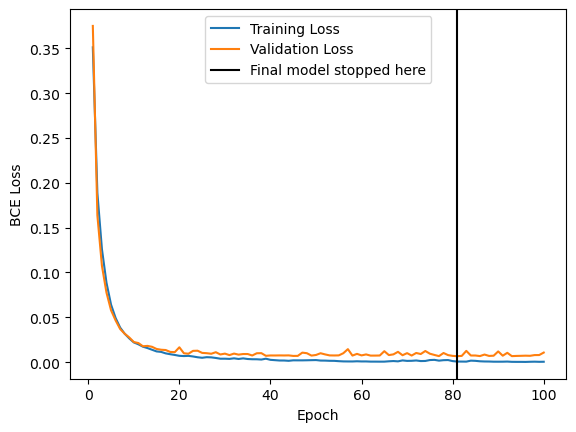

In [38]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
#plt.yscale('log')
plt.legend()

Test AUROC: 0.9991


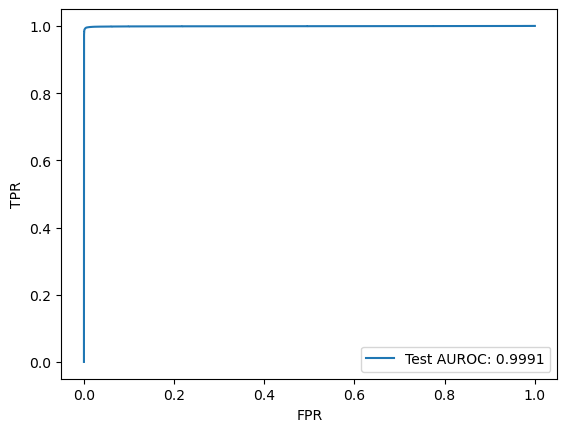

In [39]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

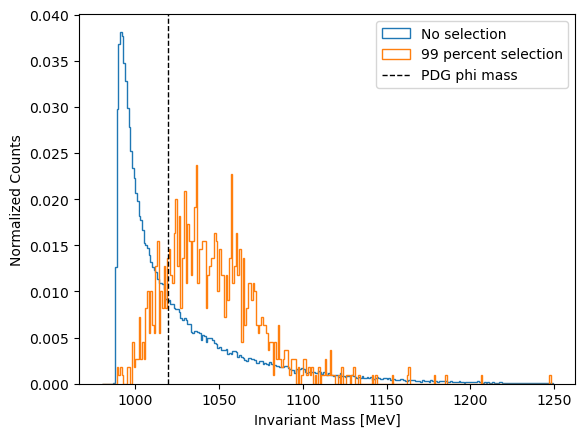

In [40]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [41]:
# Store the pretrained classifier labels
df_test["Class_pre"] = test_pred

# Save the pretrained classifier model
torch.save(final_classifier.state_dict(), "/Users/mghrear/data/ML_data/2019_pass2/models/pretrained_FakeGen_classifier_2019_pass2_run"+str(run)+"_scaled.pt")

# Setup the adversary model

## Initialize model, objective function, and optimizer

In [42]:
adv = mytools.Adversary_small(n_classes=Num_classes).to(device)
criterion_adv = nn.CrossEntropyLoss(reduction='none')  # returns loss per sample so we can weight it
opt_adv = torch.optim.Adam(adv.parameters(), lr=1e-3)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(opt_adv, gamma=1.0)


## Setup dataloaders

In [43]:
# Convert to tensor dataset and dataloader

# the structure is: feature, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_adv_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_train), (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_adv_loader = DataLoader(train_adv_dataset, batch_size=bsize, shuffle=True)

val_adv_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_val), (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float() )
val_adv_loader = DataLoader(val_adv_dataset, batch_size=bsize, shuffle=True)

# Weights are not relavent for testing
test_adv_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_test))
test_adv_loader = DataLoader(test_adv_dataset, batch_size=bsize, shuffle=True)

## Pre-train the adversary leaving classifier weights fixed

In [44]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored


Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_adv(train_adv_loader, final_classifier, adv, criterion_adv, opt_adv, scheduler_adv, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_adv(val_adv_loader, final_classifier, adv, criterion_adv, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_adv = copy.deepcopy(adv)

print("Done!")

Epoch 1
-------------------------------
Training loss: 2.443834
Validation loss: 2.314387 

Epoch 2
-------------------------------
Training loss: 2.314866
Validation loss: 2.309533 

Epoch 3
-------------------------------
Training loss: 2.304833
Validation loss: 2.305444 

Epoch 4
-------------------------------
Training loss: 2.304119
Validation loss: 2.302968 

Epoch 5
-------------------------------
Training loss: 2.303812
Validation loss: 2.307477 

Epoch 6
-------------------------------
Training loss: 2.304493
Validation loss: 2.303306 

Epoch 7
-------------------------------
Training loss: 2.303071
Validation loss: 2.302206 

Epoch 8
-------------------------------
Training loss: 2.302768
Validation loss: 2.301867 

Epoch 9
-------------------------------
Training loss: 2.303755
Validation loss: 2.302795 

Epoch 10
-------------------------------
Training loss: 2.303511
Validation loss: 2.303160 

Epoch 11
-------------------------------
Training loss: 2.302347
Validation los

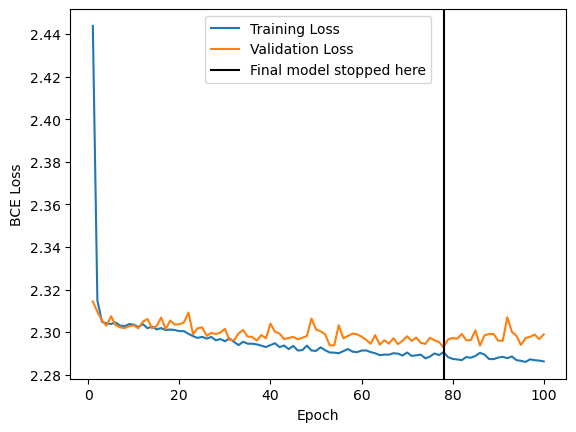

In [45]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()

# Train full adverserial neural network

# Setup dataloaders

In [46]:
# the structure is: feature, classifier label, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_full_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1), torch.from_numpy(y_adv_train),  (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_full_loader = DataLoader(train_full_dataset, batch_size=bsize, shuffle=True)

val_full_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1),  torch.from_numpy(y_adv_val),  (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float())
val_full_loader = DataLoader(val_full_dataset, batch_size=bsize, shuffle=True)


## Define loss functions

In [47]:
BCE_loss = nn.BCEWithLogitsLoss()
CE_loss = nn.CrossEntropyLoss(reduction='none') # returns loss per sample so we can weight it

def full_loss(output_clas, output_adv, target_clas, target_adv, w, lambda_):

    loss1 = BCE_loss(output_clas, target_clas )  # classification loss
    sample_losses2 = CE_loss(output_adv, target_adv)  # adversarial losses, since we set reduction='none', this is now a vector of losses, one per sample in the batch

    # Weighted mean loss over non-zero weights
    nonzero = w > 0
    loss2 = (sample_losses2[nonzero] * w[nonzero]).sum() / w[nonzero].sum()

    loss = loss1 - lambda_*loss2

    return loss
    


## Setup optimizers

In [48]:
optimizer_clas = optim.Adam(final_classifier.parameters(), lr=1e-4,betas=(0.9, 0.999))
optimizer_adv = optim.Adam(final_adv.parameters(), lr=1e-3,betas=(0.9, 0.999))

scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.999)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(optimizer_adv, gamma=0.999)

## Adversarial training

Epoch 1
-------------------------------
Classifier training loss: -11.685303
Adversary training loss: 2.348419
Classifier validation loss: -12.122358
Adversary validation loss: 2.430896
Diff score: 4.344163


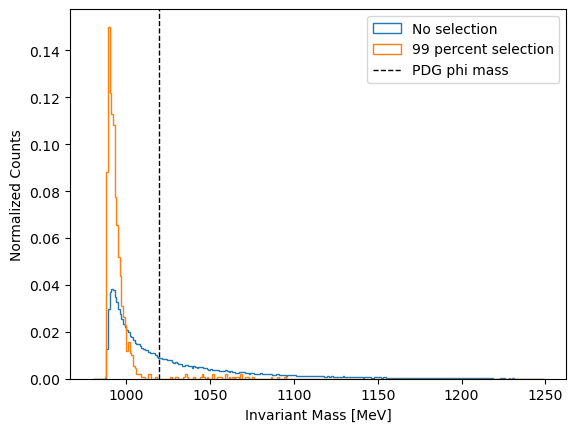

Epoch 2
-------------------------------
Classifier training loss: -11.244320
Adversary training loss: 2.283958
Classifier validation loss: -10.924582
Adversary validation loss: 2.229950
Diff score: 3.624585


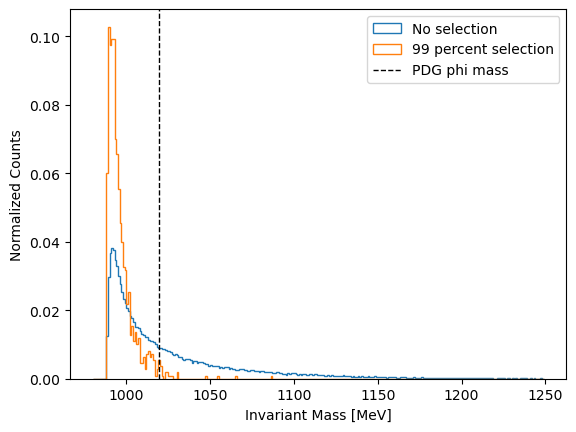

Epoch 3
-------------------------------
Classifier training loss: -11.127790
Adversary training loss: 2.256446
Classifier validation loss: -11.365022
Adversary validation loss: 2.290412
Diff score: 1.031253


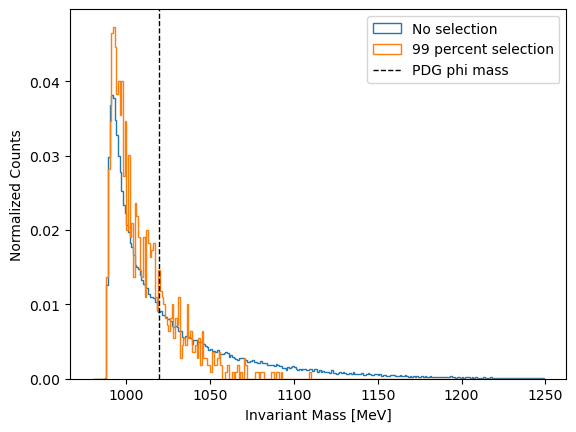

Epoch 4
-------------------------------
Classifier training loss: -11.473303
Adversary training loss: 2.304241
Classifier validation loss: -11.464780
Adversary validation loss: 2.298819
Diff score: 1.027973


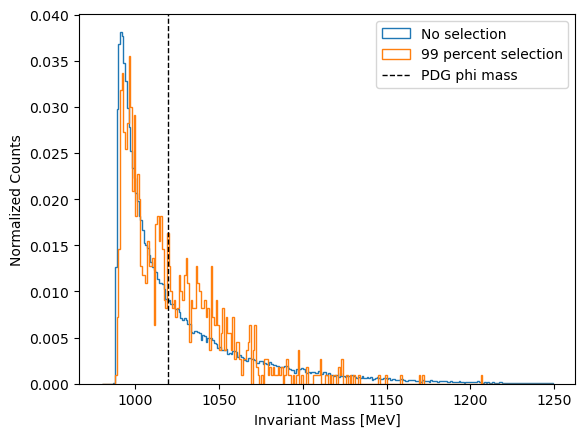

Epoch 5
-------------------------------
Classifier training loss: -11.465218
Adversary training loss: 2.297046
Classifier validation loss: -11.487305
Adversary validation loss: 2.301901
Diff score: 0.806918


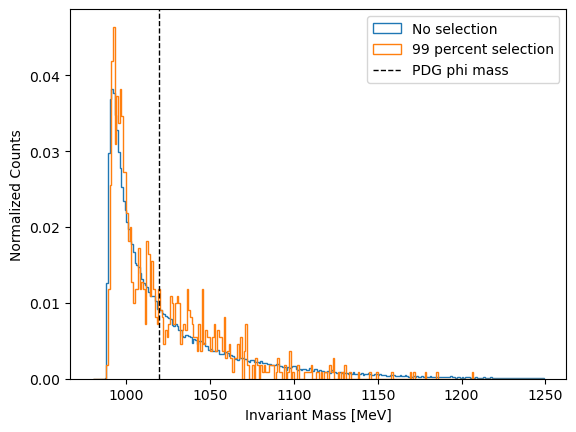

Epoch 6
-------------------------------
Classifier training loss: -11.499452
Adversary training loss: 2.303594
Classifier validation loss: -11.510859
Adversary validation loss: 2.305206
Diff score: 0.860362


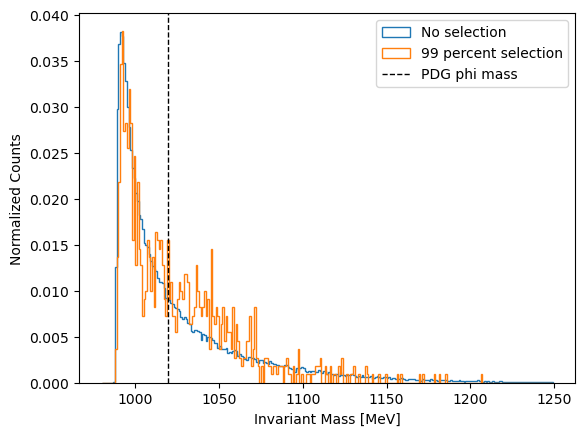

Epoch 7
-------------------------------
Classifier training loss: -11.494133
Adversary training loss: 2.300146
Classifier validation loss: -11.497485
Adversary validation loss: 2.301646
Diff score: 1.118453


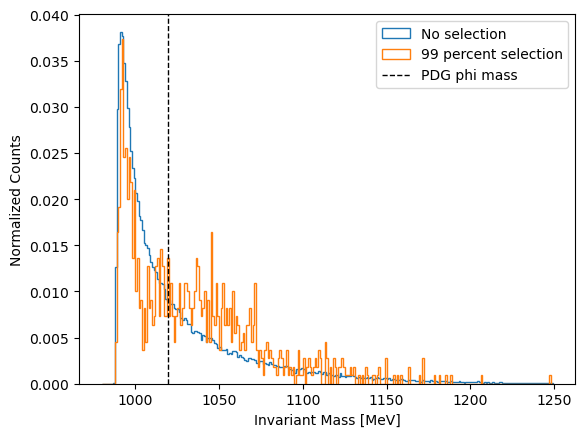

Epoch 8
-------------------------------
Classifier training loss: -11.494595
Adversary training loss: 2.301241
Classifier validation loss: -11.510386
Adversary validation loss: 2.304313
Diff score: 1.064190


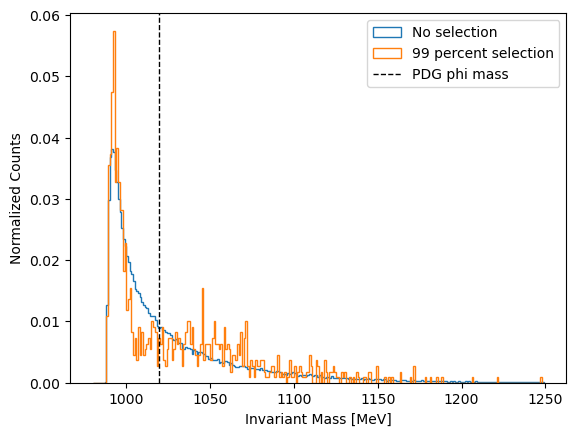

Epoch 9
-------------------------------
Classifier training loss: -11.509506
Adversary training loss: 2.303088
Classifier validation loss: -11.539802
Adversary validation loss: 2.309773
Diff score: 1.173611


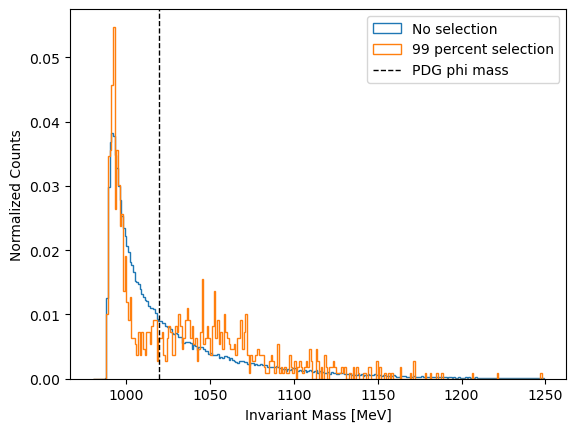

Epoch 10
-------------------------------
Classifier training loss: -11.513976
Adversary training loss: 2.302889
Classifier validation loss: -11.517725
Adversary validation loss: 2.305340
Diff score: 1.309471


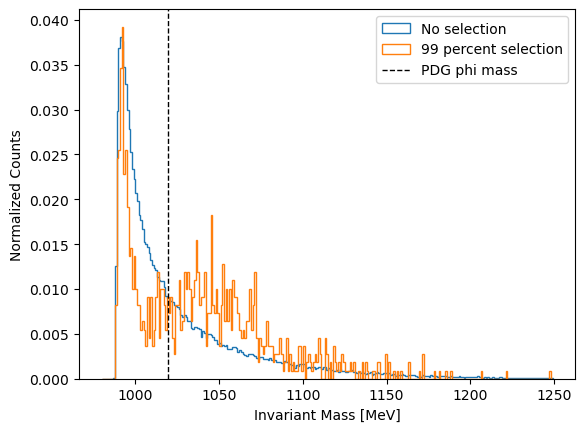

Epoch 11
-------------------------------
Classifier training loss: -11.511692
Adversary training loss: 2.303421
Classifier validation loss: -11.519775
Adversary validation loss: 2.305671
Diff score: 1.466452


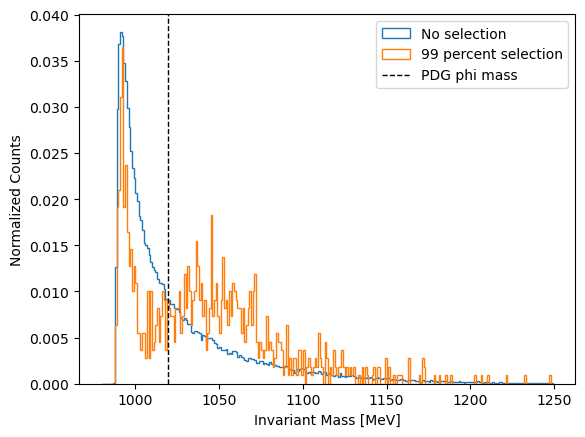

Epoch 12
-------------------------------
Classifier training loss: -11.518635
Adversary training loss: 2.304303
Classifier validation loss: -11.546405
Adversary validation loss: 2.311101
Diff score: 1.104892


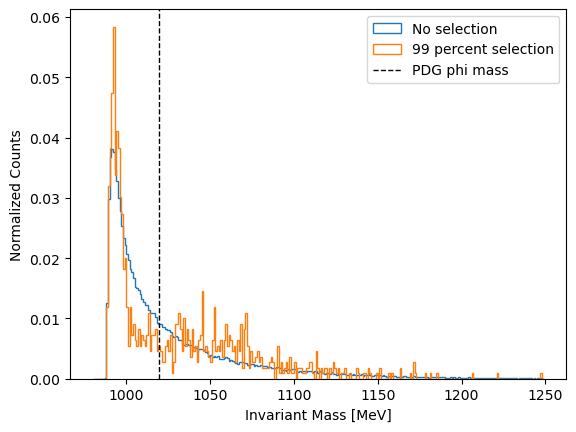

Epoch 13
-------------------------------
Classifier training loss: -11.517608
Adversary training loss: 2.304177
Classifier validation loss: -11.503068
Adversary validation loss: 2.302214
Diff score: 1.037039


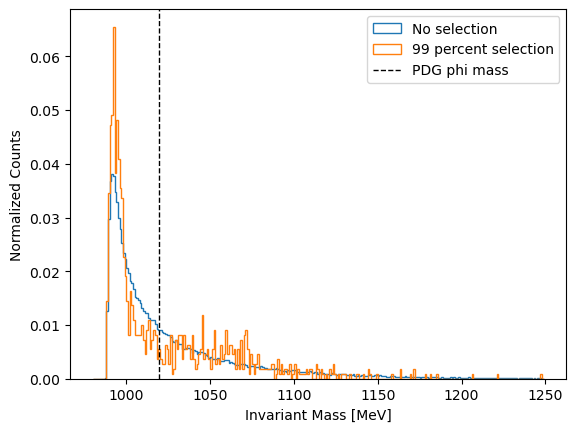

Epoch 14
-------------------------------
Classifier training loss: -11.516657
Adversary training loss: 2.303950
Classifier validation loss: -11.520457
Adversary validation loss: 2.305666
Diff score: 1.148521


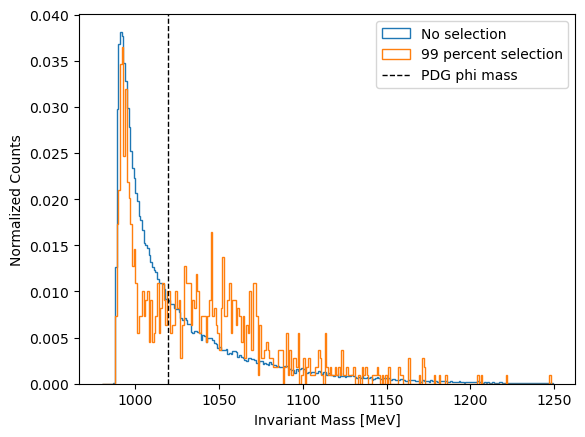

Epoch 15
-------------------------------
Classifier training loss: -11.516749
Adversary training loss: 2.304243
Classifier validation loss: -11.509455
Adversary validation loss: 2.303679
Diff score: 1.148903


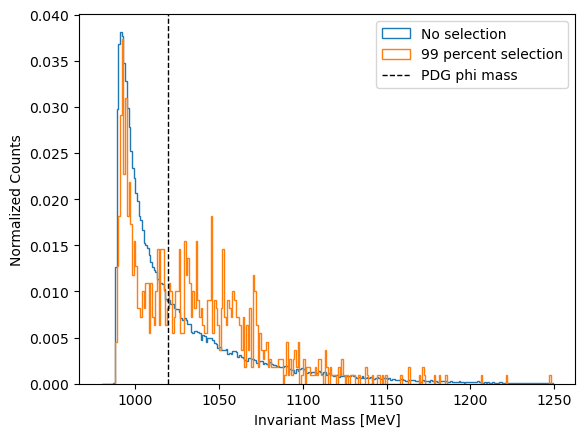

Epoch 16
-------------------------------
Classifier training loss: -11.510029
Adversary training loss: 2.302318
Classifier validation loss: -11.521123
Adversary validation loss: 2.305758
Diff score: 0.840784


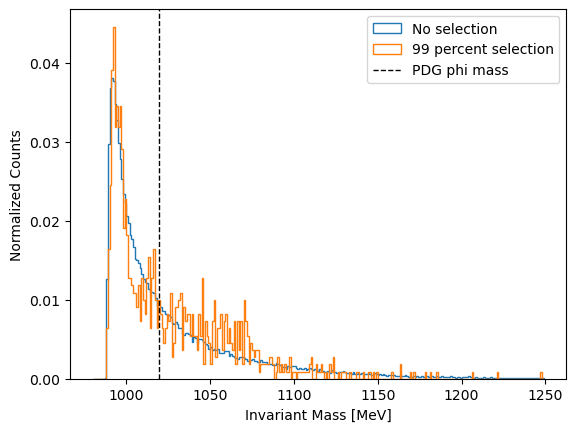

Epoch 17
-------------------------------
Classifier training loss: -11.523360
Adversary training loss: 2.304726
Classifier validation loss: -11.516058
Adversary validation loss: 2.304780
Diff score: 0.829076


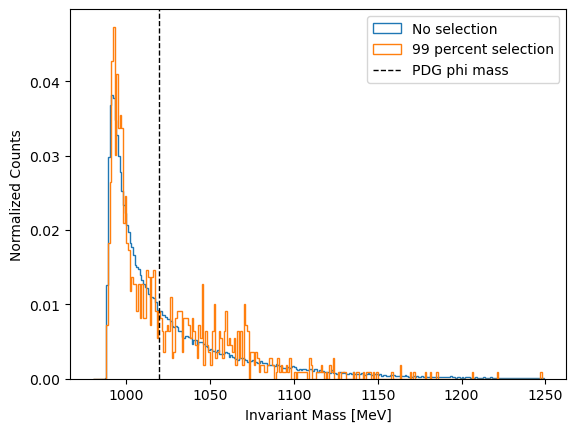

Epoch 18
-------------------------------
Classifier training loss: -11.509350
Adversary training loss: 2.303197
Classifier validation loss: -11.494038
Adversary validation loss: 2.300677
Diff score: 0.787476


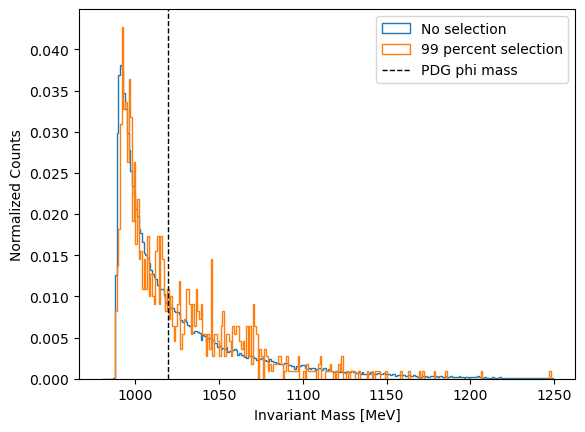

Epoch 19
-------------------------------
Classifier training loss: -11.516929
Adversary training loss: 2.304113
Classifier validation loss: -11.529073
Adversary validation loss: 2.307379
Diff score: 1.090598


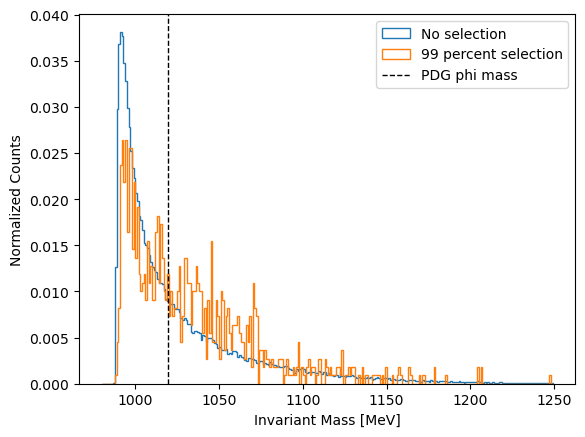

Epoch 20
-------------------------------
Classifier training loss: -11.521708
Adversary training loss: 2.305381
Classifier validation loss: -11.507696
Adversary validation loss: 2.303236
Diff score: 1.027442


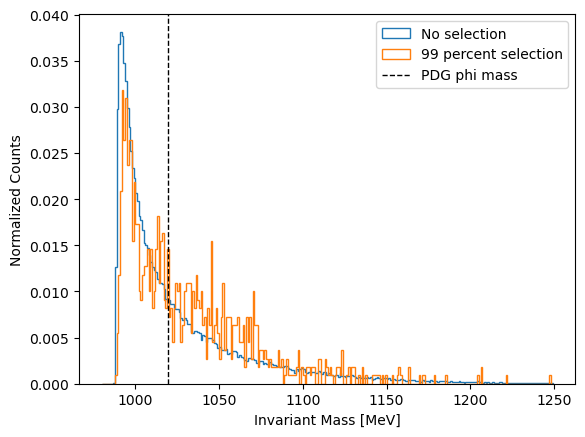

Epoch 21
-------------------------------
Classifier training loss: -11.493036
Adversary training loss: 2.299265
Classifier validation loss: -11.502634
Adversary validation loss: 2.302028
Diff score: 0.922806


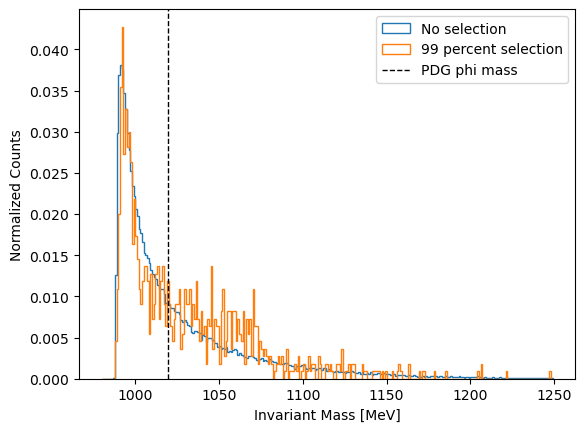

Epoch 22
-------------------------------
Classifier training loss: -11.520487
Adversary training loss: 2.304829
Classifier validation loss: -11.509780
Adversary validation loss: 2.303528
Diff score: 0.913422


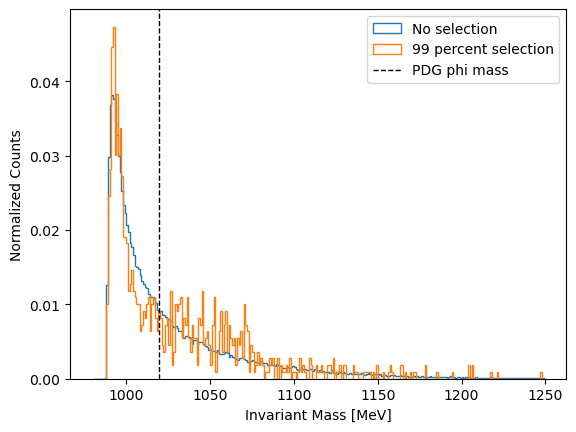

Epoch 23
-------------------------------
Classifier training loss: -11.505115
Adversary training loss: 2.302379
Classifier validation loss: -11.505268
Adversary validation loss: 2.302548
Diff score: 0.878083


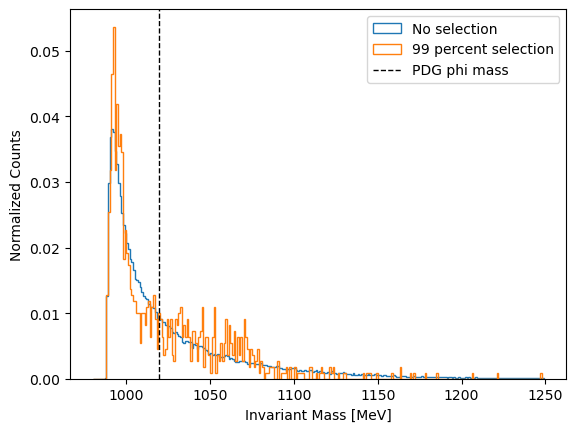

Epoch 24
-------------------------------
Classifier training loss: -11.507006
Adversary training loss: 2.302972
Classifier validation loss: -11.528174
Adversary validation loss: 2.307232
Diff score: 1.196148


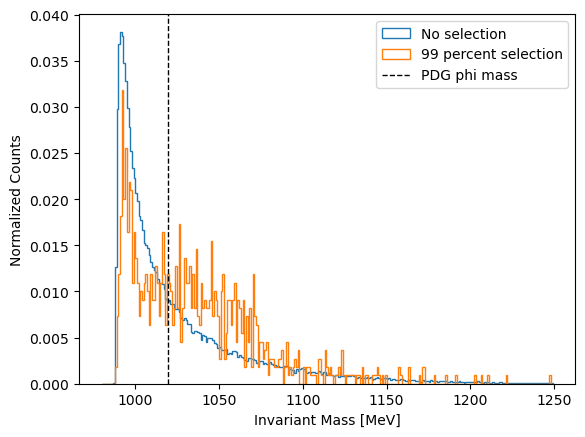

Epoch 25
-------------------------------
Classifier training loss: -11.520726
Adversary training loss: 2.304620
Classifier validation loss: -11.520076
Adversary validation loss: 2.305952
Diff score: 1.449814


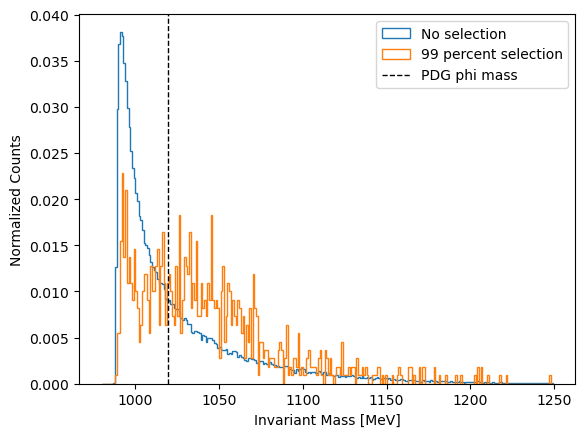

Epoch 26
-------------------------------
Classifier training loss: -11.512431
Adversary training loss: 2.302822
Classifier validation loss: -11.502486
Adversary validation loss: 2.302030
Diff score: 1.562543


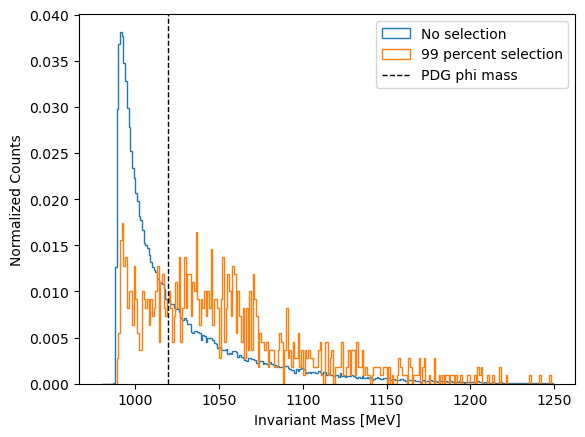

Epoch 27
-------------------------------
Classifier training loss: -11.510922
Adversary training loss: 2.303233
Classifier validation loss: -11.523721
Adversary validation loss: 2.306152
Diff score: 1.016742


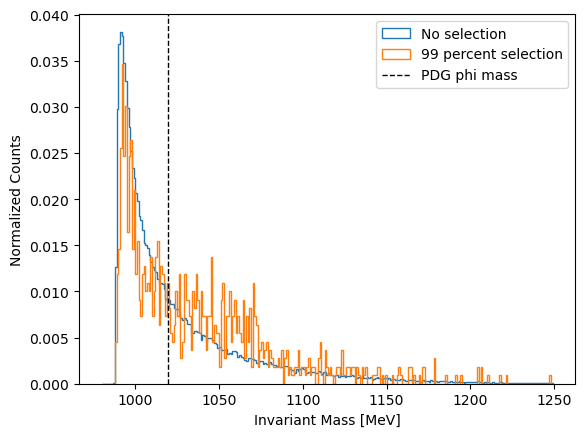

Epoch 28
-------------------------------
Classifier training loss: -11.520585
Adversary training loss: 2.304328
Classifier validation loss: -11.520253
Adversary validation loss: 2.305499
Diff score: 0.827531


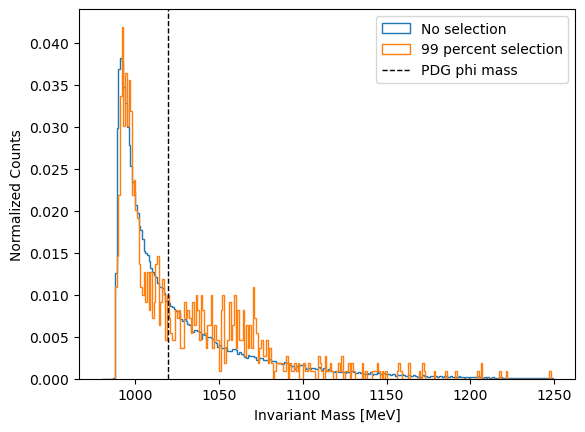

Epoch 29
-------------------------------
Classifier training loss: -11.523417
Adversary training loss: 2.304918
Classifier validation loss: -11.520759
Adversary validation loss: 2.305663
Diff score: 0.822923


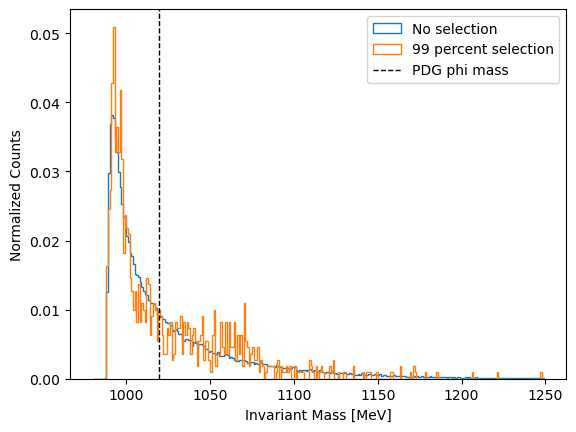

Epoch 30
-------------------------------
Classifier training loss: -11.518574
Adversary training loss: 2.305035
Classifier validation loss: -11.520633
Adversary validation loss: 2.305665
Diff score: 0.926808


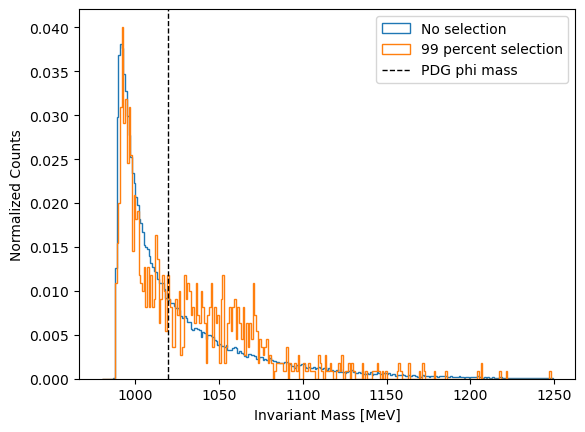

Epoch 31
-------------------------------
Classifier training loss: -11.515608
Adversary training loss: 2.303745
Classifier validation loss: -11.517124
Adversary validation loss: 2.304870
Diff score: 1.000284


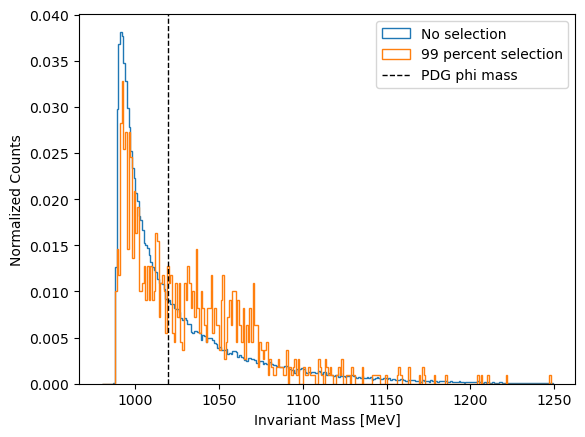

Epoch 32
-------------------------------
Classifier training loss: -11.513036
Adversary training loss: 2.303375
Classifier validation loss: -11.511407
Adversary validation loss: 2.303739
Diff score: 1.039525


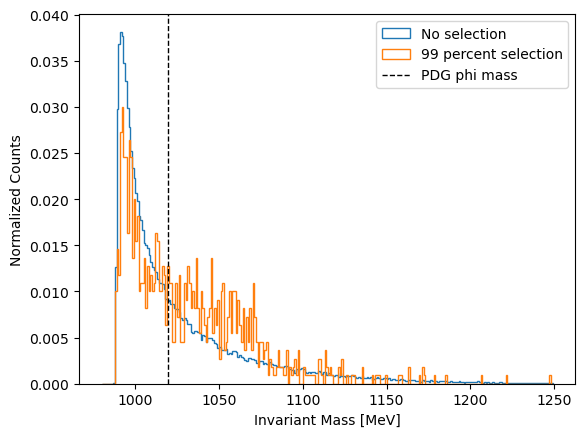

Epoch 33
-------------------------------
Classifier training loss: -11.508048
Adversary training loss: 2.302417
Classifier validation loss: -11.525169
Adversary validation loss: 2.306683
Diff score: 0.883697


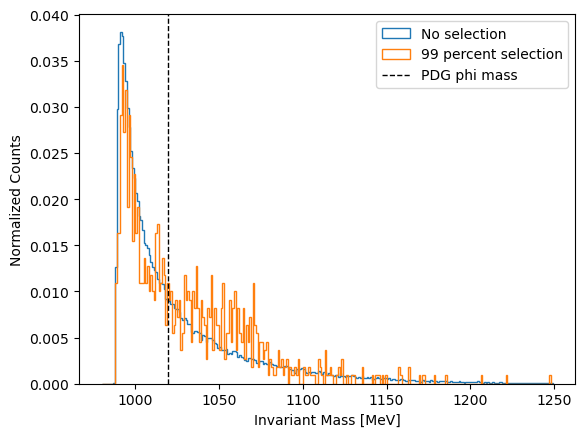

Epoch 34
-------------------------------
Classifier training loss: -11.513343
Adversary training loss: 2.303064
Classifier validation loss: -11.498408
Adversary validation loss: 2.301139
Diff score: 0.788946


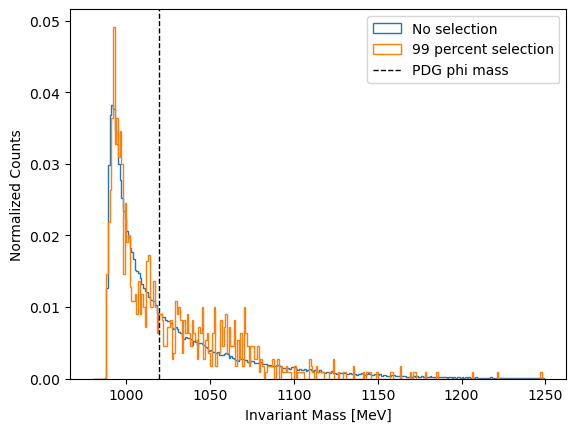

Epoch 35
-------------------------------
Classifier training loss: -11.507382
Adversary training loss: 2.302689
Classifier validation loss: -11.517421
Adversary validation loss: 2.305146
Diff score: 1.011828


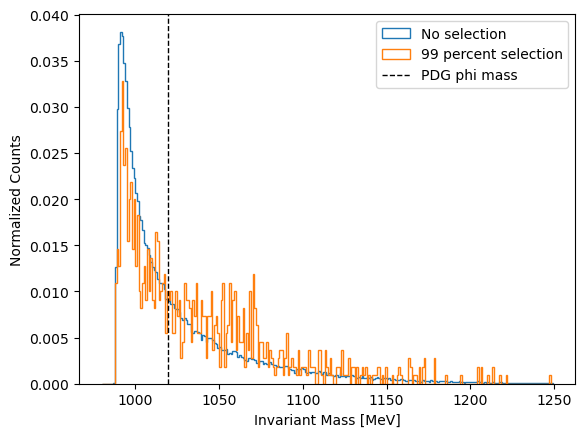

Epoch 36
-------------------------------
Classifier training loss: -11.516910
Adversary training loss: 2.304193
Classifier validation loss: -11.522565
Adversary validation loss: 2.306173
Diff score: 1.035048


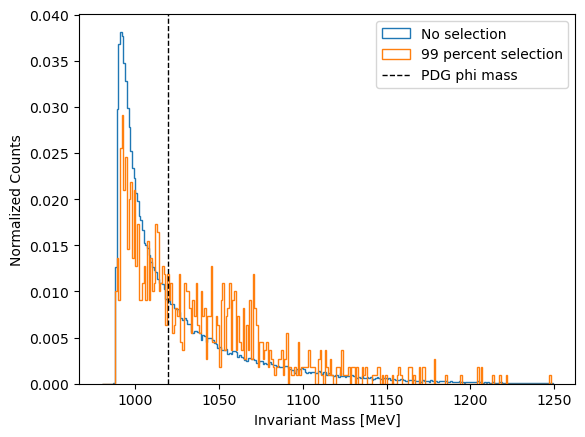

Epoch 37
-------------------------------
Classifier training loss: -11.516588
Adversary training loss: 2.304094
Classifier validation loss: -11.513432
Adversary validation loss: 2.304112
Diff score: 1.176619


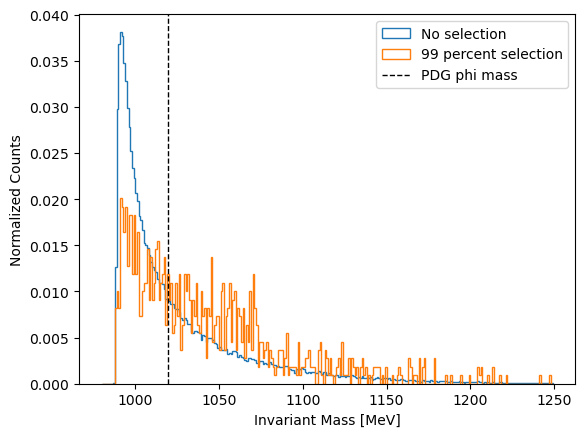

Epoch 38
-------------------------------
Classifier training loss: -11.515607
Adversary training loss: 2.303845
Classifier validation loss: -11.524809
Adversary validation loss: 2.306370
Diff score: 1.112781


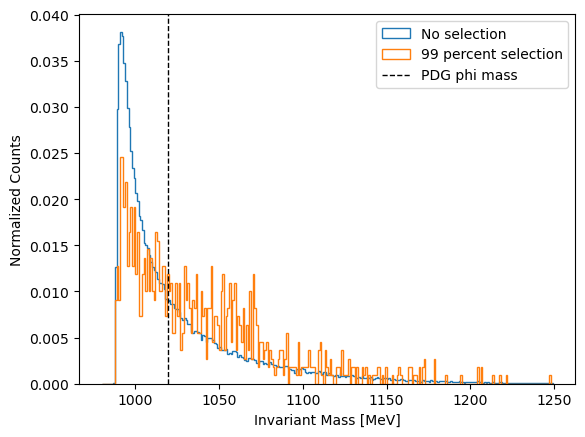

Epoch 39
-------------------------------
Classifier training loss: -11.516555
Adversary training loss: 2.304366
Classifier validation loss: -11.506604
Adversary validation loss: 2.303542
Diff score: 0.847648


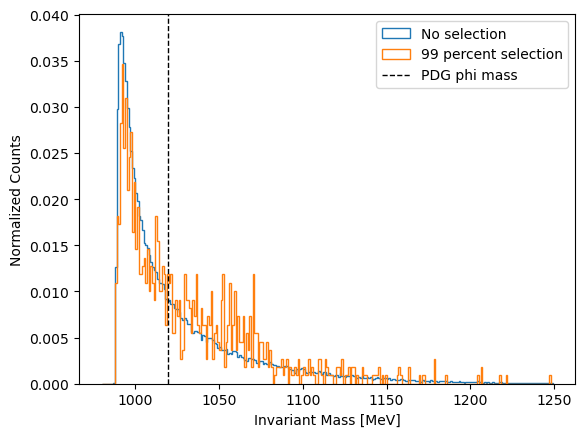

Epoch 40
-------------------------------
Classifier training loss: -11.518813
Adversary training loss: 2.304222
Classifier validation loss: -11.521827
Adversary validation loss: 2.305756
Diff score: 0.968288


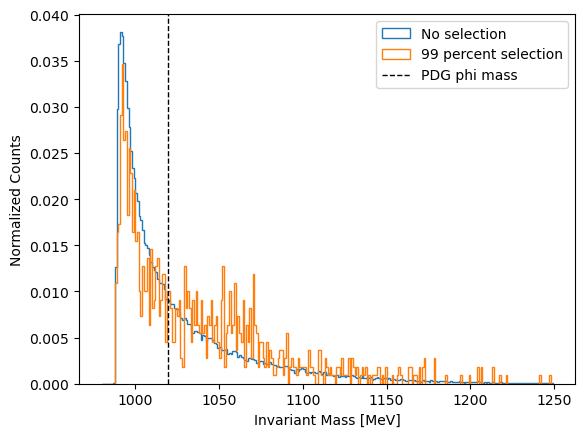

Epoch 41
-------------------------------
Classifier training loss: -11.516611
Adversary training loss: 2.304248
Classifier validation loss: -11.518275
Adversary validation loss: 2.305082
Diff score: 0.820266


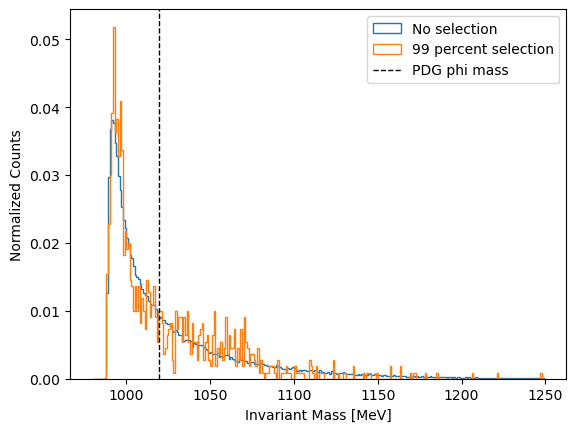

Epoch 42
-------------------------------
Classifier training loss: -11.512785
Adversary training loss: 2.303388
Classifier validation loss: -11.514225
Adversary validation loss: 2.304263
Diff score: 0.830679


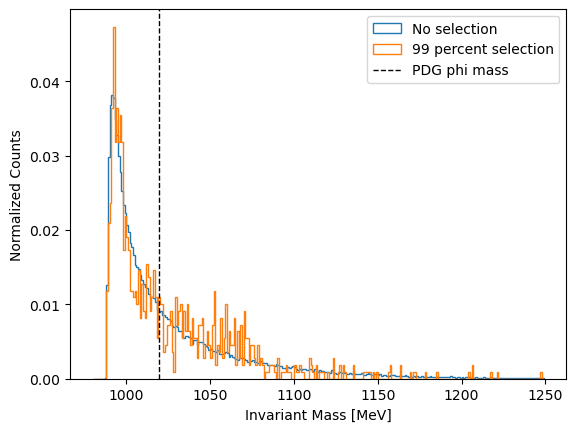

Epoch 43
-------------------------------
Classifier training loss: -11.515293
Adversary training loss: 2.303516
Classifier validation loss: -11.514850
Adversary validation loss: 2.304654
Diff score: 1.039341


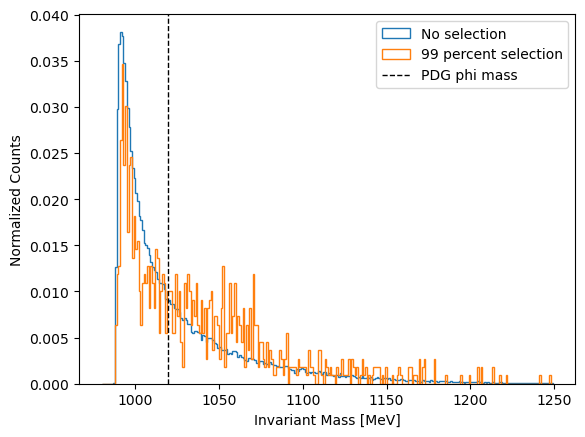

Epoch 44
-------------------------------
Classifier training loss: -11.515857
Adversary training loss: 2.303692
Classifier validation loss: -11.508385
Adversary validation loss: 2.303103
Diff score: 0.817858


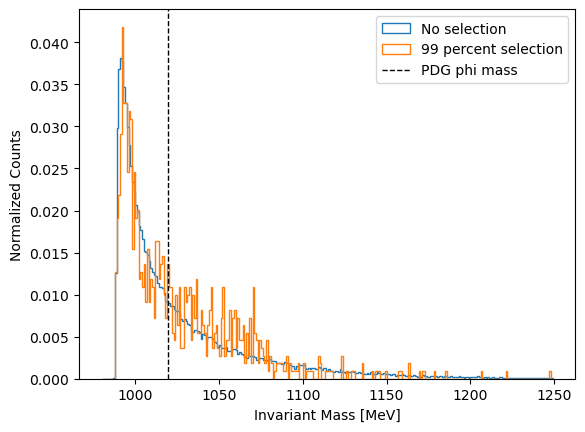

Epoch 45
-------------------------------
Classifier training loss: -11.507971
Adversary training loss: 2.303096
Classifier validation loss: -11.514518
Adversary validation loss: 2.304334
Diff score: 1.147207


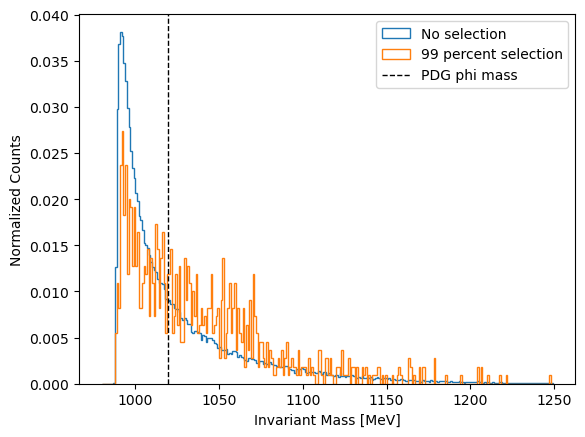

Epoch 46
-------------------------------
Classifier training loss: -11.511309
Adversary training loss: 2.302652
Classifier validation loss: -11.512989
Adversary validation loss: 2.303975
Diff score: 0.979327


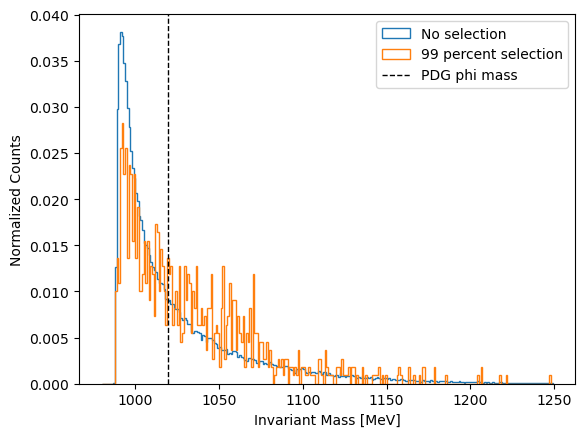

Epoch 47
-------------------------------
Classifier training loss: -11.512795
Adversary training loss: 2.303600
Classifier validation loss: -11.503993
Adversary validation loss: 2.302269
Diff score: 0.780393


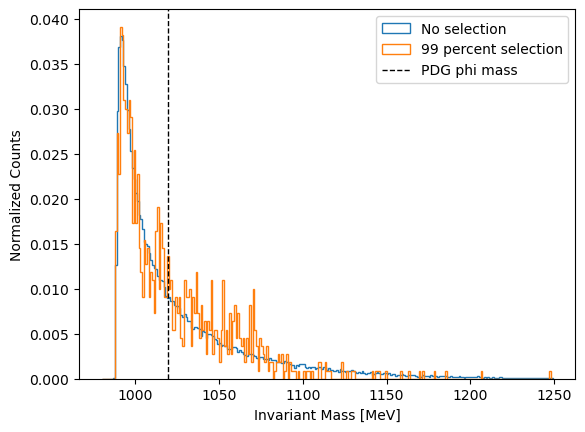

Epoch 48
-------------------------------
Classifier training loss: -11.514587
Adversary training loss: 2.303789
Classifier validation loss: -11.521948
Adversary validation loss: 2.305758
Diff score: 0.970203


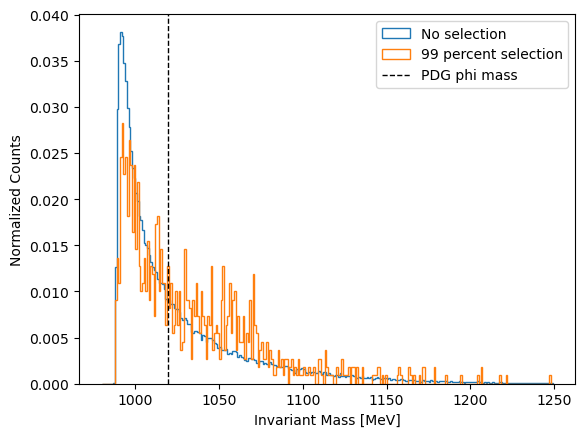

Epoch 49
-------------------------------
Classifier training loss: -11.511494
Adversary training loss: 2.302506
Classifier validation loss: -11.510805
Adversary validation loss: 2.303594
Diff score: 0.840796


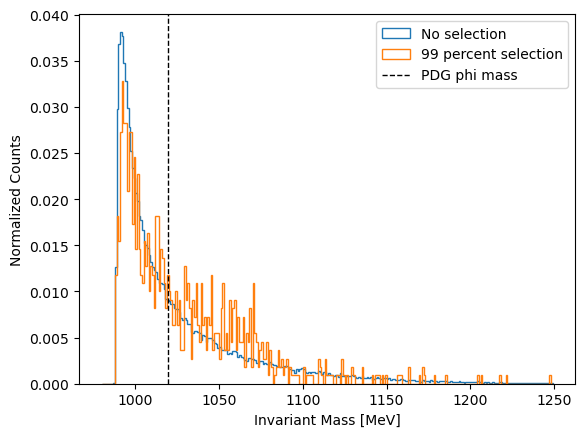

Epoch 50
-------------------------------
Classifier training loss: -11.511729
Adversary training loss: 2.303199
Classifier validation loss: -11.511832
Adversary validation loss: 2.303760
Diff score: 0.765266


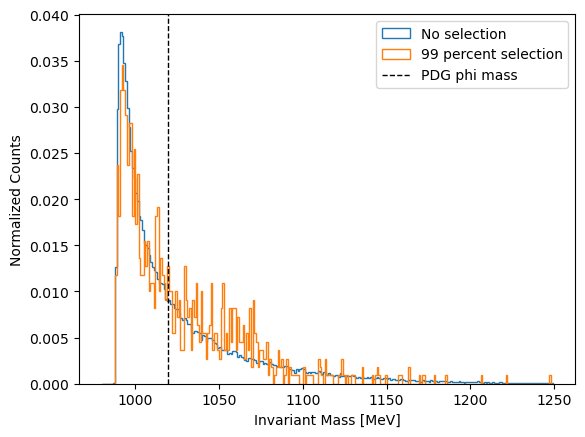

Done!


In [49]:


Training_losses_clas = np.array([])
Training_losses_adv = np.array([])
Validation_losses_clas = np.array([])
Validation_losses_adv = np.array([])
diff_scores = np.array([])


epochs = 50
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    # Train adversary and classifier
    E_clas_training_loss , E_adv_training_loss = mytools.train_full_orig(train_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, optimizer_clas, optimizer_adv, scheduler_clas, scheduler_adv, 8, device, grad_clip = False)
    Training_losses_clas = np.append(Training_losses_clas, E_clas_training_loss)
    Training_losses_adv = np.append(Training_losses_adv, E_adv_training_loss)

    # Get validation losses
    E_clas_val_loss, E_adv_val_loss = mytools.validate_full(val_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, device)
    Validation_losses_clas = np.append(Validation_losses_clas, E_clas_val_loss)
    Validation_losses_adv = np.append(Validation_losses_adv, E_adv_val_loss)

    # Get the diff_score
    df_test["Class_adv"] = mytools.test_clas(test_loader, final_classifier, device)
    df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
    per = np.percentile(df_bkg['Class_adv'],99)
    df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
    x1 = 1000*df_bkg.InvM.values
    x2 = 1000*df_cut.InvM.values
    diff_scores = np.append(diff_scores, mytools.get_diff_score(x1,x2) )

    print(f"Diff score: {diff_scores[-1]:>7f}")

    plt.figure()
    plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
    plt.hist(1000*df_cut.InvM, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
    plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
    plt.xlabel('Invariant Mass [MeV]')
    plt.ylabel('Normalized Counts')
    plt.legend()
    plt.show()

    # Keep a running copy of the model with the lowest loss
    if diff_scores[-1] == np.min(diff_scores):
        final_clas_adv = copy.deepcopy(final_classifier)
        final_adv_adv = copy.deepcopy(final_adv)

            
print("Done!")

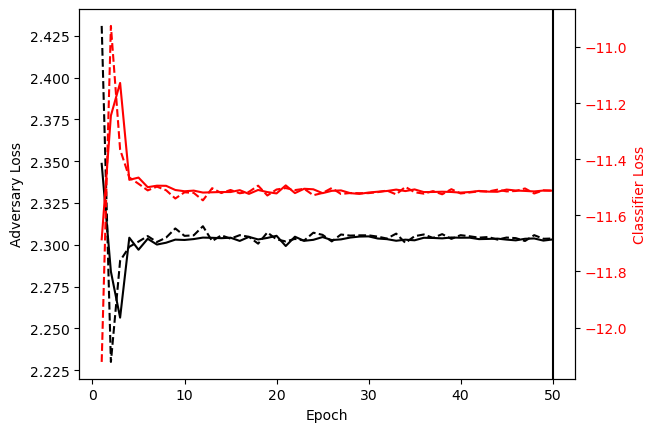

In [50]:
# Training Losses

fig, ax1 = plt.subplots()

best_epoch = np.argmin(diff_scores)+1



ax1.plot(np.arange(len(Training_losses_adv))+1, Training_losses_adv, 'k-', label='Training Adversary')
ax1.plot(np.arange(len(Validation_losses_adv))+1, Validation_losses_adv, 'k--', label='Validation Adversary')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Adversary Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

ax2 = ax1.twinx()

ax2.plot(np.arange(len(Training_losses_clas))+1, Training_losses_clas, 'r-', label='Training Classifier')
ax2.plot(np.arange(len(Validation_losses_clas))+1, Validation_losses_clas, 'r--', label='Validation Classifier')
ax2.axvline(best_epoch,label="Final model stopped here",color='k')

ax2.set_ylabel('Classifier Loss', color='r')
ax2.tick_params(axis='y', labelcolor='r')



Text(0.5, 0, 'Epoch')

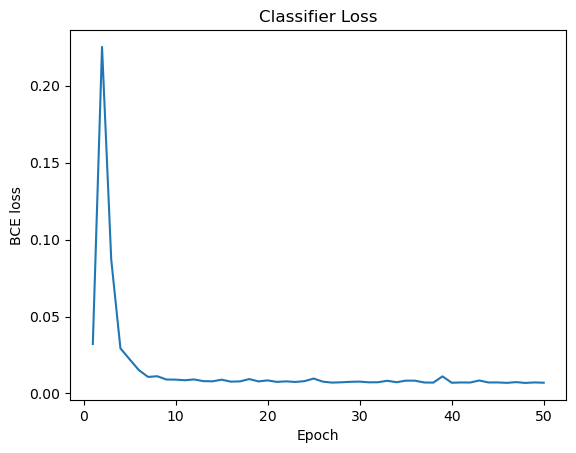

In [51]:
Validation_losses_clas+lambda_*Validation_losses_adv

plt.title("Classifier Loss")
plt.plot(np.arange(len(Training_losses_adv))+1, Validation_losses_clas+lambda_*Validation_losses_adv)
plt.ylabel("BCE loss")
plt.xlabel('Epoch')

## Test adversarially trained models

Test AUROC: 0.9987


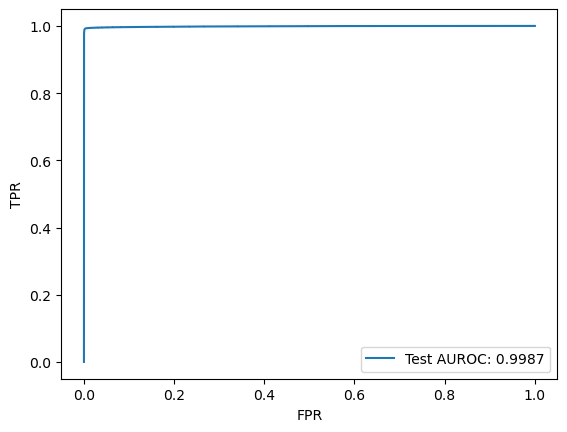

In [52]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_clas_adv, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

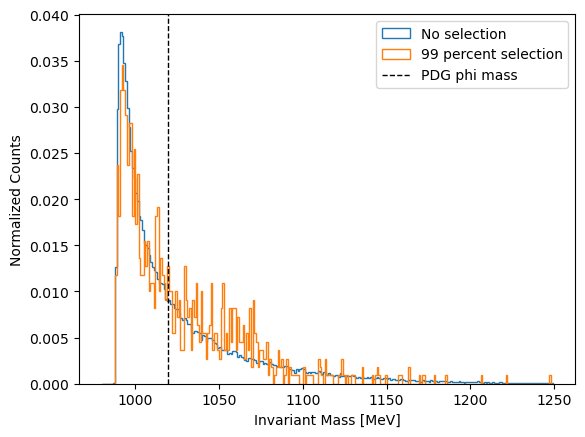

In [53]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [54]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean( np.abs( N2/np.sum(N) - M2/np.sum(M) ) / np.sqrt( ( np.sqrt(N2)/np.sum(N) )**2 + ( np.sqrt(M2)/np.sum(M) )**2 ) )

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

0.7652655787810385
1.6954545454545455


Test AUROC: 0.9987


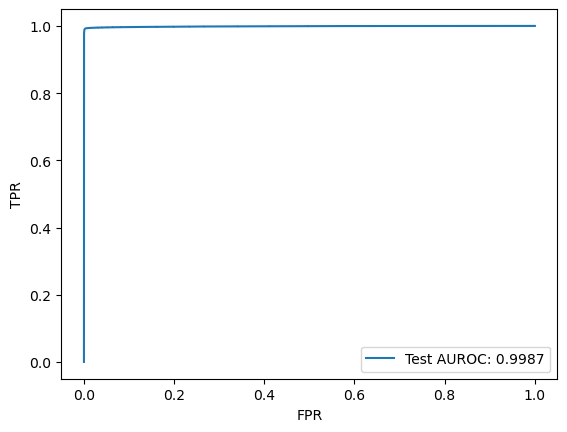

In [55]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

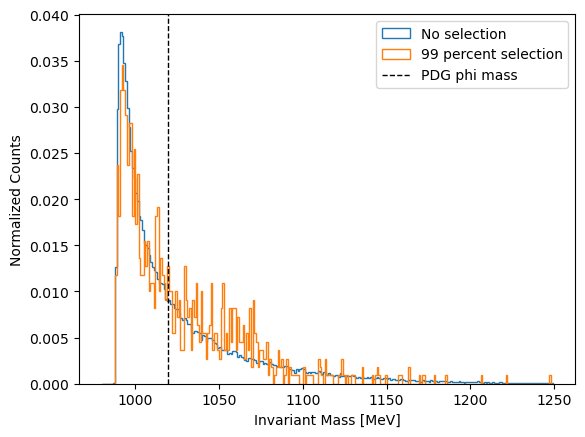

In [56]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [57]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean(np.abs(N2/np.sum(N)-M2/np.sum(M)) / (np.sqrt(N2)/np.sum(N) + np.sqrt(M2)/np.sum(M) ))

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

0.7043298900002237
1.6954545454545455


In [58]:
# Save the adversarially trained models
torch.save(final_clas_adv.state_dict(), "/Users/mghrear/data/ML_data/2019_pass2/models/FakeGen_classifier_adv_2019_pass2_run"+str(run)+"_scaled.pt")
torch.save(final_adv_adv.state_dict(), "/Users/mghrear/data/ML_data/2019_pass2/models/FakeGen_adversary_adv_2019_pass2_run"+str(run)+"_scaled.pt")
